# NISAR GIF generator

In [1]:
# standard imports to get started
import datetime
import shapely
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.animation as anim
from matplotlib.animation import PillowWriter
import ipywidgets as ipyw
import ipyleaflet

import earthdaily.earthone as eo
from earthdaily.earthone.catalog import Product, Image, ImageCollection, properties as p
from earthdaily.earthone import dynamic_compute as dc

### 1. Utils for search insar product and GIF generation

In [2]:
def get_images(geoctx, orbit=None,
               t0="2025-09-01", t1="2026-09-01",
               bands="coherence", group_by="day"):
    """
    Function to search for S1/ S2 images
    """
    
    # Make strings out of btemp and orbit
    if orbit:
        orbit = "{:03d}".format(orbit)
       
    # Then create image collection
    if bands in ["coherence", "wrapped_phase"]:
        # This is for InSAR
        insar_ic = Product.get("nasa:nisar:gunw:beta-v1").images().filter(
            t0 <= p.acquired < t1
        ).intersects(geoctx.geometry)

    elif bands in ["hh", "vv", "vh", "hv"]:
        # This for backscatter
        insar_ic = Product.get(
            "nasa:nisar:gcov:beta-v1"
        ).images().filter(
            t0 <= p.acquired < t1
        ).intersects(geoctx.geometry)
    else:
        raise ValueError(f"Could not understand {bands}")
    
    # If relative orbit is not None
    # This is for S1 only. Do not provide this for S2
    if orbit:
        insar_ic = insar_ic.collect()
        insar_ic = insar_ic.filter(
           lambda x: x.provider_id.split("_")[0] == orbit
        )
        
    
    # Finally group by and mosaic
    if group_by == "day":
        group_by_func = lambda x: (x.acquired.year, x.acquired.month, x.acquired.day)
    elif group_by == "month":
        group_by_func = lambda x: (x.acquired.year, x.acquired.month)
    
    # Group by month for longer timespans and bigger areas for speed
    groups = {}
    for img in insar_ic:
        key = group_by_func(img)
        if key not in groups:
            groups[key] = []
            
        groups[key].append(img)

    groups = {k:v for k, v in sorted(groups.items(), key=lambda x: f"{x[0][0]}{x[0][1]:02d}{x[0][2]:02d}")}
    
    return groups

In [3]:
class AnimatedGif:
    """
    GIF helper
    """
    def __init__(self, size=(640, 480)):
        self.fig = plt.figure()
        self.fig.set_size_inches(size[0] / 100, size[1] / 100)
        ax = self.fig.add_axes([0, 0, 1, 1], frameon=False, aspect=1)
        ax.set_xticks([])
        ax.set_yticks([])
        self.images = []
 
    def add(self, image, label='', clim=[-0.2, 0.8], cmap="jet", **fontargs):
        if image.shape[0] == 1:
            plt_im = plt.imshow(image[0], cmap=cmap, vmin=clim[0], vmax=clim[1], animated=True)
        else:
            plt_im = plt.imshow(np.moveaxis(image, 0, -1)/clim[1],  animated=True)
        plt_txt = plt.text(10, 30, label, **fontargs)
        self.images.append([plt_im, plt_txt])
 
    def save(self, filename):
        animation = anim.ArtistAnimation(self.fig, self.images)
        animation.save(filename, writer=PillowWriter(fps=5))

In [4]:
def make_img_coll(imglist):   
    coll = ImageCollection()
    for img in imglist:
        coll.append(img)
        
    return coll

def make_gif(stack, geoctx, outname, layer="coherence"):
    if layer=="coherence":
        clim = [0., 1.]
        cmap = "gray"
        bands = "coherence"
    elif layer=="wrapped_phase":
        clim = [-np.pi, np.pi]
        cmap = "hsv"
        bands = "phase"
    elif layer in ["vvvv", "vhvh", "hhhh", "hvhv"]:
        # In dB
        clim = [0., 0.4]
        cmap = "gray"
        bands = layer
    
    try:
        # If grouping by date
        dates = ["{}-{:02d}-{:02d}".format(*x) for x in stack]
    except:
        # If grouping by month
        dates = ["{}-{:02d}".format(*x) for x in stack]

    # We don't know the size yet. So start iterating
    count = 0
    fontargs = {"fontsize": "large",
                "color": "red",
                "backgroundcolor": "white"}
    
    for key, imglist in stack.items():
        imcoll = make_img_coll(imglist)
        data = imcoll.mosaic(bands, geocontext=geoctx, scaling="physical")
        data = data.filled(0.)
        print(data.min(), data.max(), data.shape)
       
        if count == 0:
            m = data.shape[-2]
            n = data.shape[-1]
            animated_gif = AnimatedGif(size=(m, n))
              
        label = dates[count]
        animated_gif.add(data,
                         label=label,
                         clim=clim,
                         cmap=cmap, **fontargs)
        count += 1
 
    animated_gif.save(outname)

### 2. Setup AOI

In [5]:
# Scroll around and ensure extent is right before running this cell
poly = shapely.geometry.box(41.10, 21.50, 41.18, 21.58)
poly.wkt

'POLYGON ((41.18 21.5, 41.18 21.58, 41.1 21.58, 41.1 21.5, 41.18 21.5))'

### 3. Identify unique S1 burst footprints in viewport

If you know the track number, just skip this section and use the track number in the next section

In [6]:
# Search for footprints that intersect with AOI
footprints = Product.get("nasa:nisar:gcov:beta-v1").images().intersects(poly)
print("Number of frames: ", footprints.count())
print("NISAR Tracks: ", set([x.provider_id.split("_")[0] for x in footprints]))

Number of frames:  10
NISAR Tracks:  {'071', '093'}


### 4. Create GIF

In [7]:
# This sets up projection and resolution at which data will be pulled in
epsg=32601 + int((poly.centroid.xy[0][0] + 180)/6)
geoctx = eo.geo.AOI(geometry=poly, crs=f"EPSG:{epsg}", resolution=10., align_pixels=True)

In [8]:
# Pull in backscatter data
coll = get_images(geoctx, orbit=93, t0="2025-09-01", t1="2026-03-01", bands="hh", group_by="day")
coll

{(2025,
  11,
  16): [Image: NISAR_L2_PR_GCOV_005_093_D_078_4005_DHDH_A_20251116T155513_20251116T155554_X05009_N_F_J_001
    id: nasa:nisar:gcov:beta-v1:NISAR_L2_PR_GCOV_005_093_D_078_4005_DHDH_A_20251116T155513_20251116T155554_X05009_N_F_J_001
    product: nasa:nisar:gcov:beta-v1
    created: Wed Mar  4 05:58:17 2026],
 (2025,
  12,
  10): [Image: NISAR_L2_PR_GCOV_007_093_D_078_4005_DHDH_A_20251210T155514_20251210T155555_X05009_N_F_J_001
    id: nasa:nisar:gcov:beta-v1:NISAR_L2_PR_GCOV_007_093_D_078_4005_DHDH_A_20251210T155514_20251210T155555_X05009_N_F_J_001
    product: nasa:nisar:gcov:beta-v1
    created: Wed Mar  4 06:12:47 2026],
 (2026,
  1,
  3): [Image: NISAR_L2_PR_GCOV_009_093_D_078_4005_DHDH_A_20260103T155515_20260103T155556_X05010_N_F_J_001
    id: nasa:nisar:gcov:beta-v1:NISAR_L2_PR_GCOV_009_093_D_078_4005_DHDH_A_20260103T155515_20260103T155556_X05010_N_F_J_001
    product: nasa:nisar:gcov:beta-v1
    created: Wed Mar  4 07:01:52 2026],
 (2026,
  1,
  15): [Image: NISAR_L2

0.0 175.9609375 (1, 898, 842)
0.0 172.36328125 (1, 898, 842)
0.0 183.490234375 (1, 898, 842)
0.0 166.826171875 (1, 898, 842)


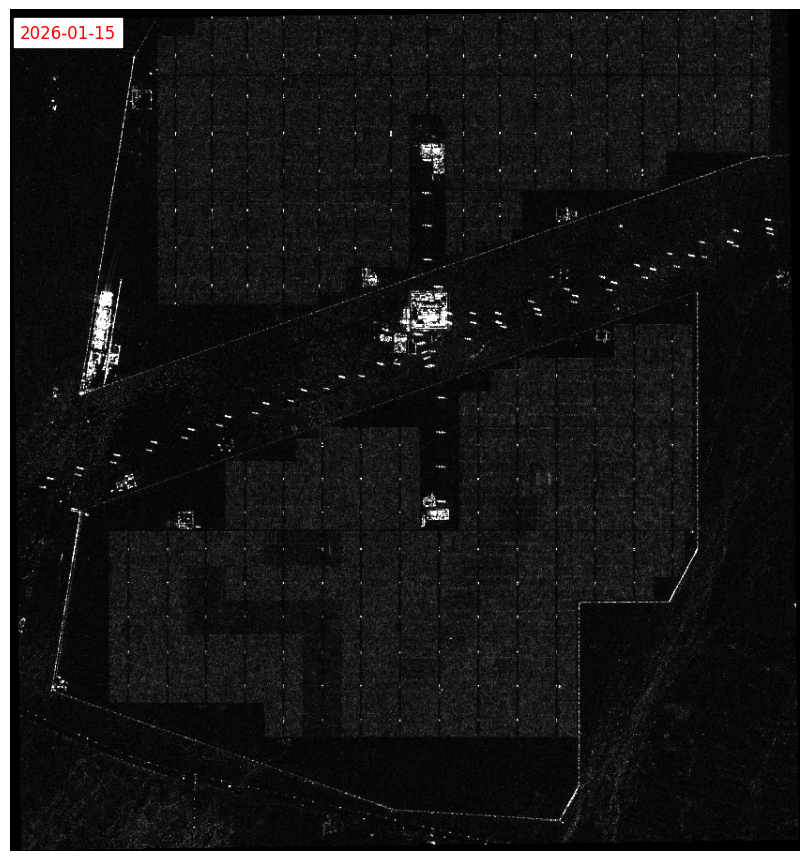

In [9]:
# Make the backscatter GIF
make_gif(coll, geoctx, "test.gif", layer="hhhh")

In [10]:
# Pull in coherence date
coll = get_images(geoctx, orbit=93, t0="2025-09-01", t1="2026-03-01", bands="coherence")
coll

{(2025,
  12,
  10): [Image: NISAR_L2_PR_GUNW_005_093_D_078_007_4000_SH_20251116T155513_20251116T155554_20251210T155514_20251210T155555_X05010_N_F_J_001
    id: nasa:nisar:gunw:beta-v1:NISAR_L2_PR_GUNW_005_093_D_078_007_4000_SH_20251116T155513_20251116T155554_20251210T155514_20251210T155555_X05010_N_F_J_001
    product: nasa:nisar:gunw:beta-v1
    created: Wed Mar  4 01:35:38 2026],
 (2026,
  1,
  3): [Image: NISAR_L2_PR_GUNW_007_093_D_078_009_4000_SH_20251210T155514_20251210T155555_20260103T155515_20260103T155556_X05010_N_F_J_001
    id: nasa:nisar:gunw:beta-v1:NISAR_L2_PR_GUNW_007_093_D_078_009_4000_SH_20251210T155514_20251210T155555_20260103T155515_20260103T155556_X05010_N_F_J_001
    product: nasa:nisar:gunw:beta-v1
    created: Wed Mar  4 03:16:16 2026],
 (2026,
  1,
  15): [Image: NISAR_L2_PR_GUNW_009_093_D_078_010_4000_SH_20260103T155515_20260103T155556_20260115T155516_20260115T155557_X05010_N_F_J_001
    id: nasa:nisar:gunw:beta-v1:NISAR_L2_PR_GUNW_009_093_D_078_010_4000_SH_202

0.0 0.9915239214897156 (1, 898, 842)
0.0 0.9892551302909851 (1, 898, 842)
0.0 0.9928895235061646 (1, 898, 842)


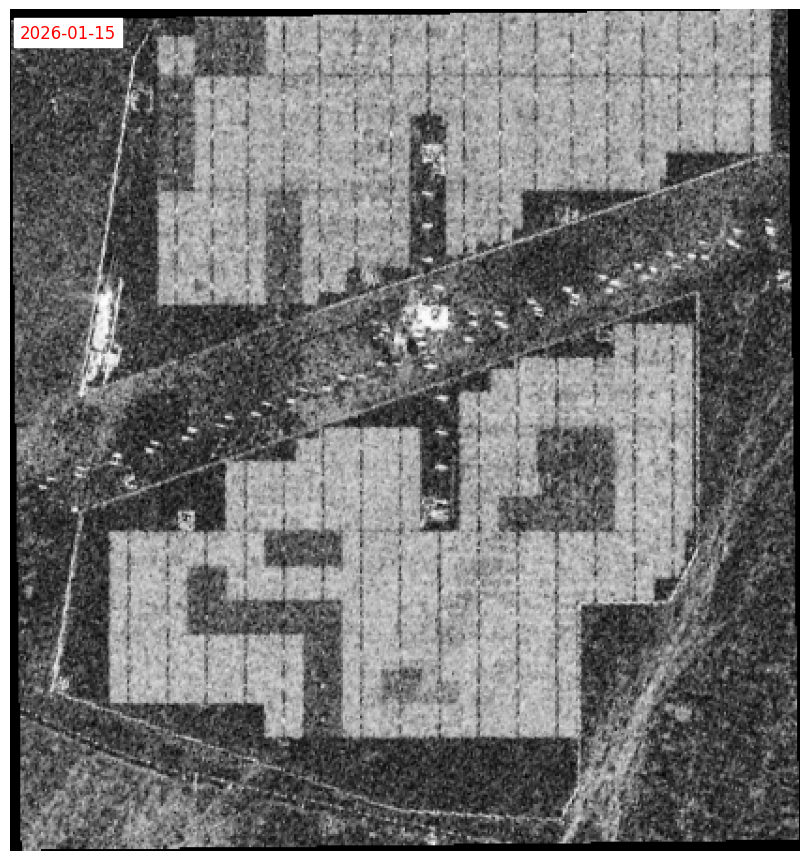

In [11]:
# Make coherence gif
make_gif(coll, geoctx, "test_coh.gif", layer="coherence")